In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np
import cv2
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from datetime import datetime
import logging
from scipy.fftpack import dct

# Helper functions for image processing and feature extraction

# Check for CUDA availability and set up device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Print CUDA information if available
if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Number of CUDA devices: {torch.cuda.device_count()}")
    print(f"Current CUDA device: {torch.cuda.current_device()}")
    print(f"Memory allocated: {torch.cuda.memory_allocated(0) / 1e6:.2f} MB")
    print(f"Memory reserved: {torch.cuda.memory_reserved(0) / 1e6:.2f} MB")
else:
    print("CUDA is not available. Using CPU instead.")


Using device: cuda
CUDA Device: NVIDIA GeForce RTX 4080
CUDA Version: 12.1
Number of CUDA devices: 1
Current CUDA device: 0
Memory allocated: 17.09 MB
Memory reserved: 23.07 MB


In [8]:
class BlockFeatureDataset(Dataset):
    """Dataset for block features and labels"""
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

def compute_saliency_map(img):
    """
    Compute saliency map for an image using simple implementation
    that doesn't rely on cv2.saliency module
    """
    # Convert to grayscale if not already
    if len(img.shape) == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray_img = img
    
    # Apply Gaussian blur
    blur = cv2.GaussianBlur(gray_img, (5, 5), 0)
    
    # Compute gradient magnitudes (Sobel operator)
    sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
    
    # Calculate magnitude of gradients
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    
    # Normalize to 0-255
    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Apply threshold to highlight salient regions
    _, saliency_map = cv2.threshold(magnitude, 50, 255, cv2.THRESH_BINARY)
    
    return saliency_map

def extract_dct_blocks(img, block_size=8):
    """Extract DCT blocks from image"""
    # Convert to grayscale if not already
    if len(img.shape) == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray_img = img
    
    height, width = gray_img.shape
    blocks = []
    
    # Extract blocks
    for i in range(0, height - block_size + 1, block_size):
        for j in range(0, width - block_size + 1, block_size):
            block = gray_img[i:i+block_size, j:j+block_size].astype(float)
            # Apply DCT
            dct_block = dct(dct(block.T, norm='ortho').T, norm='ortho')
            blocks.append({
                'position': (i, j),
                'dct_coeffs': dct_block,
                'raw_block': block
            })
    
    return blocks

def calculate_entropy(block):
    """Calculate entropy of an image block"""
    # Flatten the block and get histogram
    hist, _ = np.histogram(block.flatten(), bins=256, range=(0, 256), density=True)
    # Remove zero probabilities
    hist = hist[hist > 0]
    # Calculate entropy
    entropy_value = -np.sum(hist * np.log2(hist))
    return entropy_value

def extract_block_features(dct_blocks, saliency_map, block_size=8):
    """Extract features from DCT blocks and saliency map"""
    features = []
    
    for block in dct_blocks:
        i, j = block['position']
        
        # Get corresponding saliency block
        sal_block = saliency_map[i:i+block_size, j:j+block_size]
        avg_saliency = np.mean(sal_block)
        
        # Calculate entropy of raw block
        entropy = calculate_entropy(block['raw_block'])
        
        # Calculate variance of DCT coefficients
        dct_variance = np.var(block['dct_coeffs'])
        
        # Store features
        features.append({
            'position': block['position'],
            'avg_saliency': avg_saliency,
            'entropy': entropy,
            'dct_variance': dct_variance,
            'dct_coeffs': block['dct_coeffs']
        })
    
    return features

def label_features_heuristically(features):
    """Apply heuristic labeling for blocks based on features"""
    labeled_data = []
    
    for feature in features:
        # Adjusted heuristic for new saliency map implementation
        # Since we're now using a binary threshold at 50, average values will be different
        suitable_for_embedding = (
            feature['avg_saliency'] > 100 and  # Adjusted from 150
            feature['entropy'] > 5.0 and
            feature['dct_variance'] > 100
        )
        
        label = 1 if suitable_for_embedding else 0
        
        labeled_data.append({
            'avg_saliency': feature['avg_saliency'],
            'entropy': feature['entropy'],
            'dct_variance': feature['dct_variance'],
            'label': label
        })
    
    return labeled_data

Using device: cuda
Using device: cuda
Using device: cuda
Starting training with image directory: /home/btm0050/Research_AI_Stegno_Analysis/SteganoGan/mount/ResearchDataset/fnn
Starting training with image directory: /home/btm0050/Research_AI_Stegno_Analysis/SteganoGan/mount/ResearchDataset/fnn
Starting training with image directory: /home/btm0050/Research_AI_Stegno_Analysis/SteganoGan/mount/ResearchDataset/fnn
Parameters: num_images=20000, batch_size=64, num_epochs=30
Parameters: num_images=20000, batch_size=64, num_epochs=30
Parameters: num_images=20000, batch_size=64, num_epochs=30
Using device: cuda
Using device: cuda
Starting training with image directory: /home/btm0050/Research_AI_Stegno_Analysis/SteganoGan/mount/ResearchDataset/fnn
Starting training with image directory: /home/btm0050/Research_AI_Stegno_Analysis/SteganoGan/mount/ResearchDataset/fnn
Starting training with image directory: /home/btm0050/Research_AI_Stegno_Analysis/SteganoGan/mount/ResearchDataset/fnn
Parameters: nu

Training on: cuda
Finding image files...


Found 20000 image files to process
Found 20000 image files to process
Found 20000 image files to process
Found 20000 image files to process
Found 20000 image files to process


Processing 20000 images...


100%|██████████| 20000/20000 [1:20:44<00:00,  4.13it/s]  
Total blocks extracted: 54708408
Total blocks extracted: 54708408
Total blocks extracted: 54708408

Total blocks extracted: 54708408
Total blocks extracted: 54708408
Total blocks extracted: 54708408


...

              precision    recall  f1-score   support

           0       0.67      1.00      0.80   1826654
           1       0.00      0.00      0.00    912832

    accuracy                           0.67   2739486
   macro avg       0.33      0.50      0.40   2739486
weighted avg       0.44      0.67      0.53   2739486

🧩 Confusion Matrix:


Plot saved as logs_ML/plots/training_metrics_20250715_022540.png


[[1826654       0]
 [ 912832       0]]


Plot saved as logs_ML/plots/training_metrics_20250715_022540.png
Plot saved as logs_ML/plots/training_metrics_20250715_022540.png
Model saved as logs_ML/models/block_classifier_20250715_022540.pth
Model saved as logs_ML/models/block_classifier_20250715_022540.pth
Plot saved as logs_ML/plots/training_metrics_20250715_022540.png
Model saved as logs_ML/models/block_classifier_20250715_022540.pth
Model saved as logs_ML/models/block_classifier_20250715_022540.pth
Model saved as logs_ML/models/block_classifier_20250715_022540.pth
Model saved as logs_ML/models/block_classifier_20250715_022540.pth


Model saved as logs_ML/models/block_classifier_20250715_022540.pth


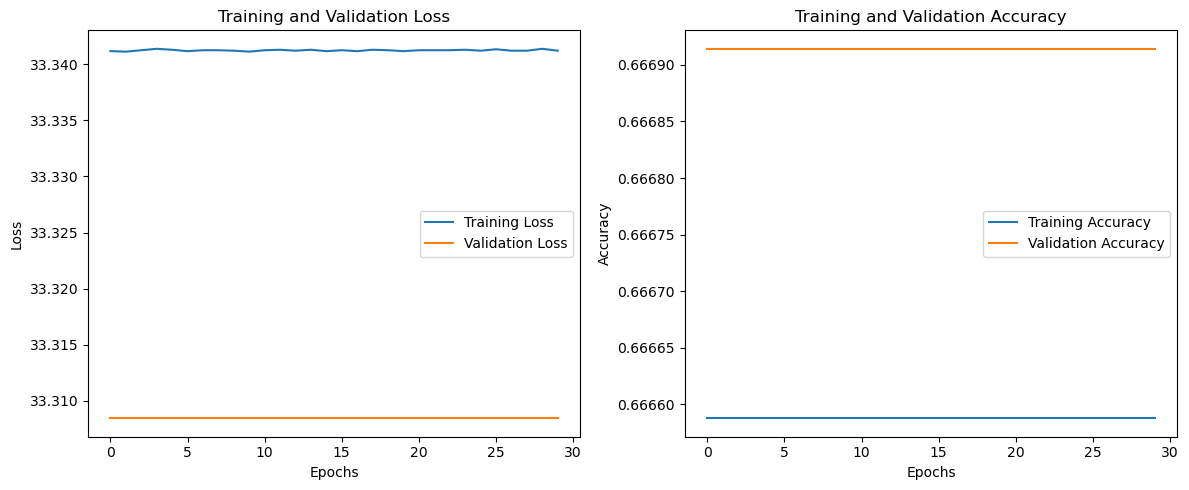

In [9]:
# Setup logging
log_dir = "logs_ML"
os.makedirs(log_dir, exist_ok=True)
log_file = os.path.join(log_dir, f"fnn_training_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log")
logging.basicConfig(filename=log_file, level=logging.INFO, 
                    format='%(asctime)s - %(levelname)s - %(message)s')
console = logging.StreamHandler()
console.setLevel(logging.INFO)
logging.getLogger('').addHandler(console)

def process_images_and_train_with_split(image_dir, num_images=20000, batch_size=64, num_epochs=30):
    """
    Process images, extract features, and train the model with 70/15/15 split.
    
    Args:
        image_dir (str): Directory containing images
        num_images (int): Number of images to process
        batch_size (int): Batch size for training
        num_epochs (int): Number of training epochs
    """
    # Get device (CPU or CUDA)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    logging.info(f"Using device: {device}")
    print(f"Training on: {device}")
    
    logging.info(f"Starting training with image directory: {image_dir}")
    logging.info(f"Parameters: num_images={num_images}, batch_size={batch_size}, num_epochs={num_epochs}")
    
    print("Finding image files...")
    image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Limit to specified number of images
    image_files = image_files[:num_images]
    print(f"Processing {len(image_files)} images...")
    logging.info(f"Found {len(image_files)} image files to process")
    
    # Process images
    labeled_data = []
    
    for img_path in tqdm(image_files):
        try:
            # Read image
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Compute saliency map
            saliency_map = compute_saliency_map(img)
            
            # Extract DCT blocks
            dct_blocks = extract_dct_blocks(img)
            
            # Extract features
            features = extract_block_features(dct_blocks, saliency_map)
            
            # Label features
            labeled = label_features_heuristically(features)
            labeled_data.extend(labeled)
        except Exception as e:
            logging.warning(f"Error processing {img_path}: {e}")
            print(f"Error processing {img_path}: {e}")
    
    total_blocks = len(labeled_data)
    print(f"Total blocks extracted: {total_blocks}")
    logging.info(f"Total blocks extracted: {total_blocks}")
    
    # Convert to DataFrame for easier manipulation
    df = pd.DataFrame(labeled_data)
    
    # Check class balance
    class_counts = df['label'].value_counts()
    print(f"Class distribution: {class_counts.to_dict()}")
    logging.info(f"Class distribution: {class_counts.to_dict()}")
    
    # Balance dataset if needed
    if class_counts[0] > class_counts[1] * 2:  # If class 0 is more than twice class 1
        df_1 = df[df["label"] == 1]
        df_0 = df[df["label"] == 0].sample(len(df_1) * 2, random_state=42)  # 2:1 ratio
        df_balanced = pd.concat([df_0, df_1]).sample(frac=1, random_state=42).reset_index(drop=True)
        print(f"Balanced dataset size: {len(df_balanced)}")
        logging.info(f"Balanced dataset size: {len(df_balanced)}")
    else:
        df_balanced = df
    
    # Feature and label extraction
    X = df_balanced[["avg_saliency", "entropy", "dct_variance"]].values
    y = df_balanced["label"].values.reshape(-1, 1)
    
    # Convert to tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    
    # First split: 70% train, 30% temp (for validation and test)
    X_train, X_temp, y_train, y_temp = train_test_split(X_tensor, y_tensor, test_size=0.3, random_state=42)
    
    # Second split: Split temp into validation and test (50/50 which is 15% of original data each)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    
    logging.info(f"Data split: Train: {len(X_train)} blocks, Validation: {len(X_val)} blocks, Test: {len(X_test)} blocks")
    print(f"Data split: Train: {len(X_train)} blocks, Validation: {len(X_val)} blocks, Test: {len(X_test)} blocks")
    
    # Create datasets and dataloaders
    train_dataset = BlockFeatureDataset(X_train, y_train)
    val_dataset = BlockFeatureDataset(X_val, y_val)
    test_dataset = BlockFeatureDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    # Define neural net
    class EmbedNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(3, 64),
                nn.ReLU(),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, 1),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.net(x)
    
    model = EmbedNet().to(device)  # Move model to GPU if available
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Log model parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    logging.info(f"Model parameters - Total: {total_params}, Trainable: {trainable_params}")
    print(f"Model parameters - Total: {total_params}, Trainable: {trainable_params}")
    
    # Metrics storage
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    # Train loop
    logging.info("Starting model training...")
    print("Training model...")
    
    # Track time for performance monitoring
    start_time = datetime.now()
    
    for epoch in range(num_epochs):
        epoch_start_time = datetime.now()
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for features, labels in train_loader:
            # Move data to appropriate device
            features = features.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            predicted = (outputs > 0.6).int()
            total += labels.size(0)
            correct += (predicted == labels.int()).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for features, labels in val_loader:  # Using val_loader instead of test_loader
                features = features.to(device)
                labels = labels.to(device)
                
                outputs = model(features)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                predicted = (outputs > 0.6).int()
                total += labels.size(0)
                correct += (predicted == labels.int()).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        
        # Save metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        # Calculate time per epoch for performance monitoring
        epoch_time = datetime.now() - epoch_start_time
        
        log_message = f"Epoch {epoch+1}/{num_epochs} — Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Time: {epoch_time}"
        print(log_message)
        logging.info(log_message)
        
        # If using CUDA, log memory usage
        if torch.cuda.is_available():
            mem_allocated = torch.cuda.memory_allocated(device) / 1e6  # Convert to MB
            mem_reserved = torch.cuda.memory_reserved(device) / 1e6
            logging.info(f"GPU Memory - Allocated: {mem_allocated:.2f} MB, Reserved: {mem_reserved:.2f} MB")
    
    # Total training time
    total_time = datetime.now() - start_time
    logging.info(f"Total training time: {total_time}")
    print(f"Total training time: {total_time}")
    
    # Final evaluation on test set
    model.eval()
    all_preds = []
    all_labels = []
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            predicted = (outputs > 0.6).int()
            total += labels.size(0)
            correct += (predicted == labels.int()).sum().item()
            
            # Move to CPU for sklearn metrics
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.int().cpu().numpy())
    
    test_loss = test_loss / len(test_loader)
    test_acc = correct / total
    
    logging.info(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
    
    # Classification report
    report = classification_report(all_labels, all_preds, output_dict=True)
    logging.info("\n📊 Classification Report:")
    logging.info(f"Precision (Class 0): {report['0']['precision']:.4f}")
    logging.info(f"Recall (Class 0): {report['0']['recall']:.4f}")
    logging.info(f"F1-score (Class 0): {report['0']['f1-score']:.4f}")
    logging.info(f"Precision (Class 1): {report['1']['precision']:.4f}")
    logging.info(f"Recall (Class 1): {report['1']['recall']:.4f}")
    logging.info(f"F1-score (Class 1): {report['1']['f1-score']:.4f}")
    logging.info(f"Accuracy: {report['accuracy']:.4f}")
    
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds))
    print("🧩 Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    
    # Plot training & validation loss and accuracy
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Training Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    
    plt.tight_layout()
    
    # Save plot
    plots_dir = os.path.join(log_dir, "plots")
    os.makedirs(plots_dir, exist_ok=True)
    plot_filename = os.path.join(plots_dir, f"training_metrics_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png")
    plt.savefig(plot_filename)
    logging.info(f"Plot saved as {plot_filename}")
    
    # Save the model
    models_dir = os.path.join(log_dir, "models")
    os.makedirs(models_dir, exist_ok=True)
    model_filename = os.path.join(models_dir, f"block_classifier_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth")
    torch.save(model.state_dict(), model_filename)
    logging.info(f"Model saved as {model_filename}")
    print(f"Model saved as {model_filename}")
    
    return model, {'train': train_dataset, 'val': val_dataset, 'test': test_dataset}, {
        'train_losses': train_losses, 
        'val_losses': val_losses, 
        'train_accuracies': train_accuracies, 
        'val_accuracies': val_accuracies,
        'test_acc': test_acc
    }

# Run the improved training function with the specified image directory
image_dir = "/home/btm0050/Research_AI_Stegno_Analysis/SteganoGan/mount/ResearchDataset/fnn"
model, datasets, metrics = process_images_and_train_with_split(image_dir)

# Show the final plot
plt.show()

In [10]:
# Test function with smaller sample size for quick verification
def visualize_block_classification(image_path, model):
    """
    Visualize block classification on a single image
    
    Args:
        image_path (str): Path to the image file
        model (nn.Module): Trained model for block classification
    """
    # Get device for consistency
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Compute saliency map
    saliency_map = compute_saliency_map(img)
    
    # Extract DCT blocks
    dct_blocks = extract_dct_blocks(img)
    
    # Extract features
    features = extract_block_features(dct_blocks, saliency_map)
    
    # Prepare visualization image
    vis_img = img.copy()
    block_size = 8
    
    # Process blocks
    model.eval()
    with torch.no_grad():
        for i, feature in enumerate(features):
            # Extract position
            pos = dct_blocks[i]['position']
            
            # Get feature tensor and move to device
            feat_tensor = torch.tensor([[
                feature['avg_saliency'],
                feature['entropy'],
                feature['dct_variance']
            ]], dtype=torch.float32).to(device)
            
            # Predict
            output = model(feat_tensor)
            is_suitable = output.item() > 0.6
            
            # Draw rectangle around block
            color = (0, 255, 0) if is_suitable else (255, 0, 0)  # Green if suitable, Red if not
            cv2.rectangle(
                vis_img,
                (pos[1], pos[0]),
                (pos[1] + block_size, pos[0] + block_size),
                color,
                1
            )
    
    # Display images
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(saliency_map, cmap='gray')  # Changed to grayscale for the binary saliency map
    plt.title("Saliency Map")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(vis_img)
    plt.title("Block Classification (Green: Suitable, Red: Unsuitable)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Count blocks
    total_blocks = len(features)
    suitable_blocks = sum([1 for f in features if model(torch.tensor([[f['avg_saliency'], f['entropy'], f['dct_variance']]], dtype=torch.float32).to(device)).item() > 0.6])
    
    print(f"Total blocks: {total_blocks}")
    print(f"Suitable blocks: {suitable_blocks} ({suitable_blocks/total_blocks*100:.2f}%)")
    print(f"Unsuitable blocks: {total_blocks - suitable_blocks} ({(total_blocks - suitable_blocks)/total_blocks*100:.2f}%)")

# Find a test image from the dataset and visualize classification
import glob

# Try to find an image to test
test_images = glob.glob(os.path.join(image_dir, "*.jpg")) + \
              glob.glob(os.path.join(image_dir, "*.png")) + \
              glob.glob(os.path.join(image_dir, "*.jpeg"))

if test_images:
    test_image = test_images[0]  # Just use the first image
    print(f"Testing with image: {test_image}")
    visualize_block_classification(test_image, model)
else:
    print("No test images found in the specified directory.")

No test images found in the specified directory.
